<a href="https://colab.research.google.com/github/hykim-1/Study/blob/main/CNN_GRU_smartphone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np, pandas as pd
from keras.utils import to_categorical
import matplotlib.pyplot as plt, seaborn as sns
import keras
from keras import layers
import tensorflow as tf
from sklearn.metrics import f1_score, classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support

SEED=42
np.random.seed(SEED); tf.random.set_seed(SEED)

In [7]:
# ----- Loader (동일) -----
def load_file(fp): return pd.read_csv(fp, header=None, delim_whitespace=True).values
def load_group(files, prefix=''): return np.dstack([load_file(prefix+name) for name in files])
def load_dataset_group(group, prefix=''):
    fp = prefix + group + '/Inertial Signals/'
    files = [f'total_acc_{a}_{group}.txt' for a in ['x','y','z']]
    files+= [f'body_acc_{a}_{group}.txt'  for a in ['x','y','z']]
    files+= [f'body_gyro_{a}_{group}.txt' for a in ['x','y','z']]
    X = load_group(files, fp); y = load_file(prefix+group+f'/y_{group}.txt'); return X,y

def load_dataset(prefix=''):
    base = '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/'
    trainX, trainy = load_dataset_group('train', base)
    testX,  testy  = load_dataset_group('test',  base)
    trainy = trainy - 1; testy = testy - 1
    print("Shapes:", "trainX",trainX.shape,"trainy",trainy.shape,"| testX",testX.shape,"testy",testy.shape)
    return trainX, trainy, testX, testy

X_train, y_train, X_test, y_test = load_dataset()
num_classes = len(np.unique(y_train))
y_train_oh = to_categorical(y_train); y_test_oh = to_categorical(y_test)
timesteps, n_channels = X_train.shape[1], X_train.shape[2]
input_shape = (timesteps, n_channels)

/tmp/ipython-input-1652620365.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  def load_file(fp): return pd.read_csv(fp, header=None, delim_whitespace=True).values
/tmp/ipython-input-1652620365.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  def load_file(fp): return pd.read_csv(fp, header=None, delim_whitespace=True).values
/tmp/ipython-input-1652620365.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  def load_file(fp): return pd.read_csv(fp, header=None, delim_whitespace=True).values
/tmp/ipython-input-1652620365.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  def load_file(fp): return

Shapes: trainX (7352, 128, 9) trainy (7352, 1) | testX (2947, 128, 9) testy (2947, 1)


/tmp/ipython-input-1652620365.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  def load_file(fp): return pd.read_csv(fp, header=None, delim_whitespace=True).values
/tmp/ipython-input-1652620365.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  def load_file(fp): return pd.read_csv(fp, header=None, delim_whitespace=True).values


In [8]:
# ----- CNN + GRU -----
def build_cnn_gru(input_shape, num_classes):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GRU(128)(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="CNN_GRU")

model = build_cnn_gru(input_shape, num_classes)
model.summary()

Model: "CNN_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,262 (501.02 KB)

 Trainable params: 127,878 (499.52 KB)

 Non-trainable params: 384 (1.50 KB)

In [4]:
opt = keras.optimizers.Adam(1e-3)
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
callbacks=[keras.callbacks.EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)]
history = model.fit(X_train, y_train_oh, epochs=30, batch_size=64, verbose=2, callbacks=callbacks)

probs = model.predict(X_test, verbose=0)
y_pred = probs.argmax(axis=1); y_true = y_test.flatten()
acc = accuracy_score(y_true, y_pred); f1m = f1_score(y_true, y_pred, average="macro")
print(f"[TEST] Acc={acc:.4f} | Macro-F1={f1m:.4f}")
print("\n[TEST] Classification Report"); print(classification_report(y_true, y_pred, digits=4))

Epoch 1/30
115/115 - 9s - 75ms/step - accuracy: 0.8452 - loss: 0.4007
Epoch 2/30
115/115 - 2s - 19ms/step - accuracy: 0.9465 - loss: 0.1290
Epoch 3/30
115/115 - 2s - 21ms/step - accuracy: 0.9499 - loss: 0.1160
Epoch 4/30
115/115 - 2s - 15ms/step - accuracy: 0.9480 - loss: 0.1277
Epoch 5/30
115/115 - 2s - 21ms/step - accuracy: 0.9533 - loss: 0.1073
Epoch 6/30
115/115 - 2s - 13ms/step - accuracy: 0.9547 - loss: 0.1009
Epoch 7/30
115/115 - 1s - 10ms/step - accuracy: 0.9475 - loss: 0.1253
Epoch 8/30
115/115 - 1s - 8ms/step - accuracy: 0.9524 - loss: 0.1061
Epoch 9/30
115/115 - 1s - 9ms/step - accuracy: 0.9559 - loss: 0.0981
Epoch 10/30
115/115 - 1s - 9ms/step - accuracy: 0.9574 - loss: 0.0924
Epoch 11/30
115/115 - 1s - 9ms/step - accuracy: 0.9593 - loss: 0.0900
Epoch 12/30
115/115 - 1s - 9ms/step - accuracy: 0.9604 - loss: 0.0850
Epoch 13/30
115/115 - 1s - 9ms/step - accuracy: 0.9652 - loss: 0.0824
Epoch 14/30
115/115 - 1s - 9ms/step - accuracy: 0.9656 - loss: 0.0783
Epoch 15/30
115/115 - 

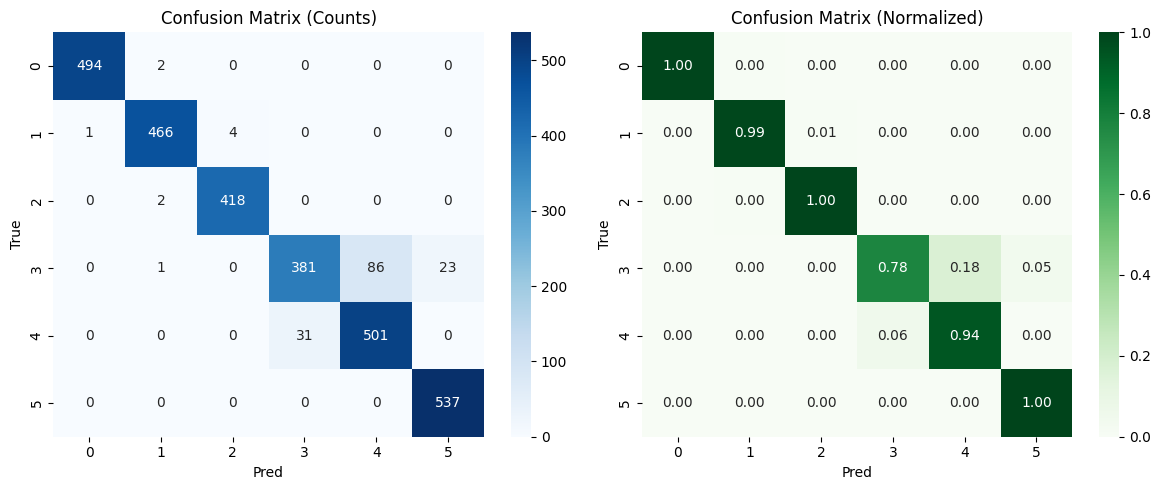

In [5]:
cm = confusion_matrix(y_true, y_pred); cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title('Confusion Matrix (Counts)'); plt.xlabel('Pred'); plt.ylabel('True')
plt.subplot(1,2,2); sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens'); plt.title('Confusion Matrix (Normalized)'); plt.xlabel('Pred'); plt.ylabel('True')
plt.tight_layout(); plt.show()

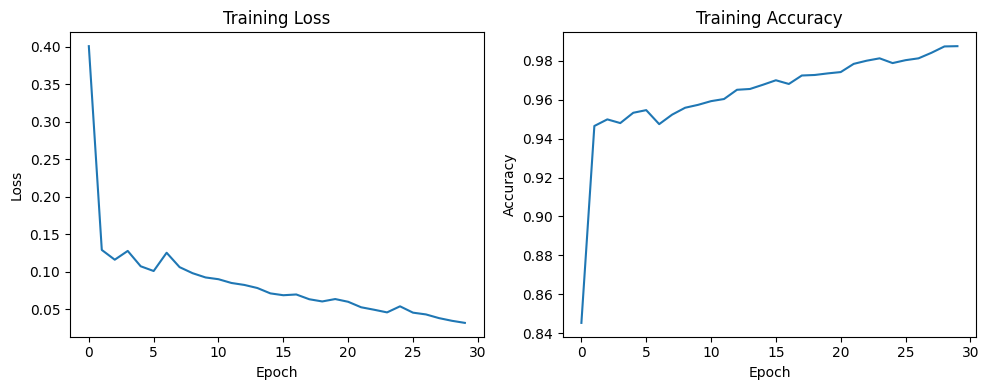

In [9]:
hist = history.history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(hist.get('loss', [])); plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.subplot(1,2,2); plt.plot(hist.get('accuracy', [])); plt.title('Training Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.tight_layout(); plt.show()

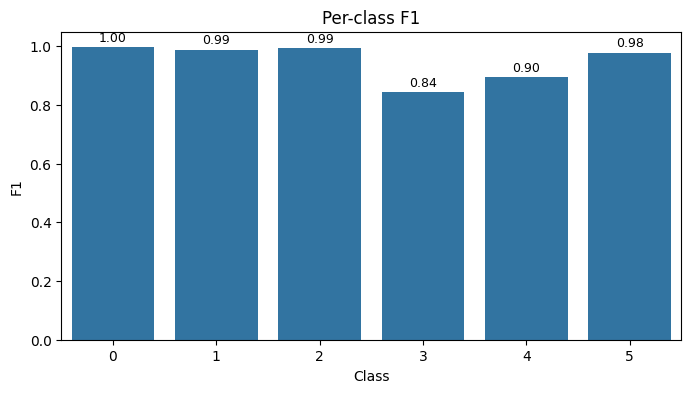


TF: 2.19.0 | Keras: 3.10.0 | Backend: tensorflow


In [10]:
prec, rec, f1s, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
classes = np.arange(len(f1s))
plt.figure(figsize=(8,4)); sns.barplot(x=classes, y=f1s); plt.title('Per-class F1'); plt.xlabel('Class'); plt.ylabel('F1')
for i, v in enumerate(f1s): plt.text(i, v+0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=9)
plt.ylim(0,1.05); plt.show()

print("\nTF:", tf.__version__, "| Keras:", keras.__version__, "| Backend:", keras.backend.backend())
